Ensemble classification methods in breast cancer

Random Forest Accuracy: 0.9390018484288355
Gradient Boosting Accuracy: 0.9020332717190388
AdaBoost Accuracy: 0.9020332717190388
Voting (Hard) Accuracy: 0.9371534195933456
Voting (Soft) Accuracy: 0.9408502772643254


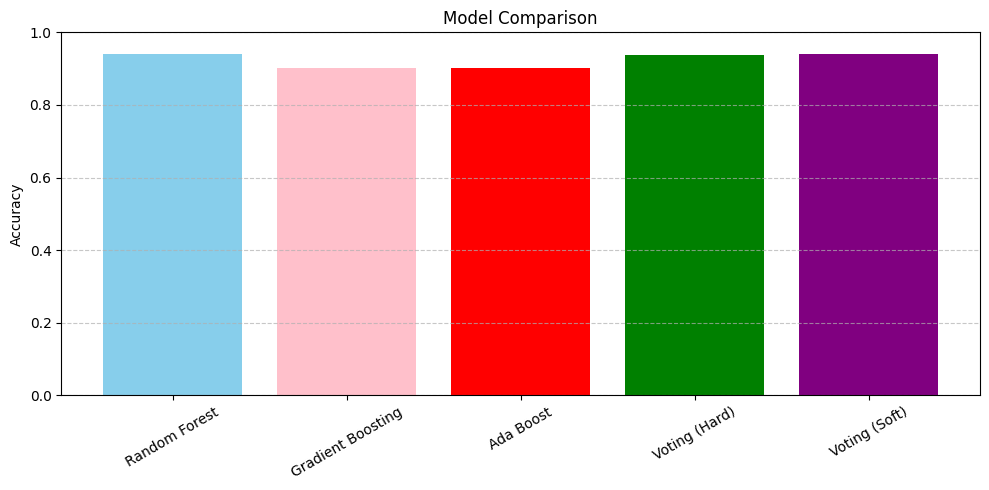

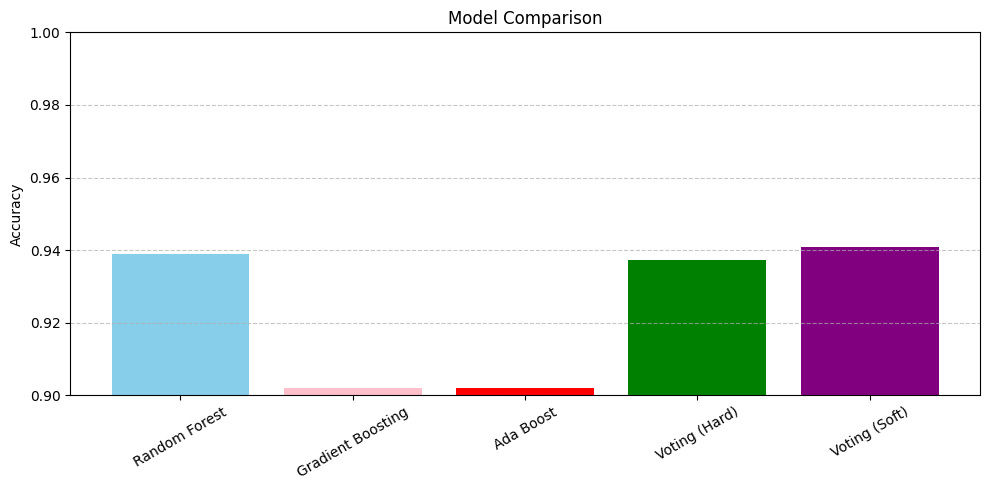

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt

# Import the dataset into our variable data
data = load_breast_cancer()
X, y = data.data, data.target

# Split the data into train and test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.95, random_state=42)

# We normalize the feature values using StandardScale to improve the model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------- Random Forest -----------

# We train our RandomForest model with the train data and calculate the accuracy comparing the test with the prediccted data
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

# -------- Gradient Boosting -----------

# We train or GradientBoosting model with the train data and calculate the accuracy comparing the test with the prediccted data
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", accuracy_gb)

# -------- Ada Boost -----------

# We train or AdaBoost model with the train data and calculate the accuracy comparing the test with the prediccted data
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train_scaled, y_train)
y_pred_ada = ada.predict(X_test_scaled)
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", accuracy_ada)

# -------- Voting Classifier -----------

lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(random_state=42)

# Train the two models separatelly
lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

# Hard Voting mode
voting_hard = VotingClassifier(estimators=[('lr', lr), ('rf', rf)], voting='hard')
voting_hard.fit(X_train_scaled, y_train)
y_pred_hard = voting_hard.predict(X_test_scaled)
accuracy_hard = accuracy_score(y_test, y_pred_hard)
print("Voting (Hard) Accuracy:", accuracy_hard)

# Soft Voting mode
voting_soft = VotingClassifier(estimators=[('lr', lr), ('rf', rf)], voting='soft')
voting_soft.fit(X_train_scaled, y_train)
y_pred_soft = voting_soft.predict(X_test_scaled)
accuracy_soft = accuracy_score(y_test, y_pred_soft)
print("Voting (Soft) Accuracy:", accuracy_soft)

# -------- Comparing Bar Graphic -----------

plt.figure(figsize=(10, 5))
plt.bar('Random Forest', accuracy_rf, color='skyblue')
plt.bar('Gradient Boosting', accuracy_gb, color='pink')
plt.bar('Ada Boost', accuracy_ada, color='red')
plt.bar('Voting (Hard)', accuracy_hard, color='green')
plt.bar('Voting (Soft)', accuracy_soft, color='purple')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.xticks(rotation=30)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# We zoom in to see better the difference between each one

plt.figure(figsize=(10, 5))
plt.bar('Random Forest', accuracy_rf, color='skyblue')
plt.bar('Gradient Boosting', accuracy_gb, color='pink')
plt.bar('Ada Boost', accuracy_ada, color='red')
plt.bar('Voting (Hard)', accuracy_hard, color='green')
plt.bar('Voting (Soft)', accuracy_soft, color='purple')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.xticks(rotation=30)
plt.ylim(0.9, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Questions:
1. Which method performed best and why?

In these case with 0.95 of test data, the models that fits best are Voting Soft, Random Forest and Voting Hard

2. How does bagging differ from boosting in your results?

3. When would you choose a VotingClassifier over individual models?

4. Can you think of ways to improve model performance even further? (e.g., hyper-parameter tuning, feature selection, etc)
